In [1]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import matplotlib.pyplot as plt

%matplotlib inline

def show_image(img, title=None):
    plt.figure(figsize=(8, 6))
    if title:
        plt.title(title)
    if isinstance(img, np.ndarray):
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.axis('off')
    plt.show()

In [14]:
def image_pad(bin_img, pad_h, pad_w):
    H, W = bin_img.shape
    out = np.zeros((H + 2*pad_h, W + 2*pad_w), dtype=np.uint8)
    out[pad_h:pad_h+H, pad_w:pad_w+W] = bin_img
    return out

def morph_erosion(bin_img, struct):
    H, W = bin_img.shape
    sh, sw = struct.shape
    pad_h = sh // 2
    pad_w = sw // 2
    padded = image_pad(bin_img, pad_h, pad_w)
    out = np.zeros_like(bin_img)
    for r in range(H):
        for c in range(W):
            region = padded[r:r+sh, c:c+sw]
            if np.sum(region * struct) == np.sum(struct):
                out[r, c] = 1
            else:
                out[r, c] = 0
    return out

def morph_dilation(bin_img, struct):
    H, W = bin_img.shape
    sh, sw = struct.shape
    pad_h = sh // 2
    pad_w = sw // 2
    padded = image_pad(bin_img, pad_h, pad_w)
    out = np.zeros_like(bin_img)
    for r in range(H):
        for c in range(W):
            region = padded[r:r+sh, c:c+sw]
            if np.sum(region * struct) > 0:
                out[r, c] = 1
            else:
                out[r, c] = 0
    return out

def morph_closing(bin_img, struct):
    eroded = morph_erosion(bin_img, struct)
    closed = morph_dilation(eroded, struct)
    return closed

In [15]:
def staffl_detection(gray_img, close_len=25, gap_thresh=9):
    bin_img = (gray_img < 128).astype(np.uint8)
    struct = np.ones((1, close_len), dtype=np.uint8)
    closed_img = morph_closing(bin_img, struct)
    H, W = closed_img.shape
    line_rows = []
    for r in range(H):
        black_count = np.sum(closed_img[r, :] == 1)
        if black_count > (0.5 * W):
            line_rows.append(r)
    merged = []
    if line_rows:
        merged.append(line_rows[0])
        for i in range(1, len(line_rows)):
            if (line_rows[i] - line_rows[i-1]) >= gap_thresh:
                merged.append(line_rows[i])
    return merged

def treble_bass_grp(lines, big_jump=50):
    sorted_rows = sorted(lines)
    treble, bass = [], []
    if not sorted_rows:
        return treble, bass
    use_treble = True
    treble.append(sorted_rows[0])
    for i in range(1, len(sorted_rows)):
        if (sorted_rows[i] - sorted_rows[i-1]) > big_jump:
            use_treble = not use_treble
        if use_treble:
            treble.append(sorted_rows[i])
        else:
            bass.append(sorted_rows[i])
    return treble, bass

def lin_sp_estimation(lines):
    if len(lines) < 2:
        return 10
    first_four = sorted(lines)[:4]
    gaps = []
    for i in range(len(first_four) - 1):
        gaps.append(first_four[i+1] - first_four[i])
    if not gaps:
        return 10
    return int(sum(gaps)/len(gaps))


In [2]:





def inv_norm(pil_img):
    arr = np.array(pil_img.convert('L'), dtype=np.float32) / 255.0
    return 1.0 - arr

def corr_cross(m_arr, t_arr):
    H, W = m_arr.shape
    hT, wT = t_arr.shape
    score_map = np.zeros_like(m_arr)
    for r in range(H - hT):
        for c in range(W - wT):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)
    return score_map

class s_bol:
    def __init__(self, x, y, w, h, sym_type, conf=0.0, pitch='_'):
        self.x = x
        self.y = y
        self.w = w
        self.h = h
        self.sym_type = sym_type
        self.conf = conf
        self.pitch = pitch
    def info_str(self):
        return f"{self.y} {self.x} {self.h} {self.w} {self.pitch} {self.conf}"

def dtct_symbols(m_arr, t_arr, label, conf_thresh=0.9):
    score_map = corr_cross(m_arr, t_arr)
    max_val = score_map.max()
    if max_val <= 0:
        return []
    hT, wT = t_arr.shape
    found = []
    for r in range(score_map.shape[0]):
        for c in range(score_map.shape[1]):
            if score_map[r, c] >= (conf_thresh * max_val):
                confidence = (score_map[r, c] / max_val) * 100.0
                found.append(s_bol(x=c, y=r, w=wT, h=hT, 
                                    sym_type=label, 
                                    conf=round(confidence,2)))
    return found

def comp_iou(s_a, s_b):
    xA = max(s_a.x, s_b.x)
    yA = max(s_a.y, s_b.y)
    xB = min(s_a.x+s_a.w, s_b.x+s_b.w)
    yB = min(s_a.y+s_a.h, s_b.y+s_b.h)
    inter = max(0, xB - xA) * max(0, yB - yA)
    union = (s_a.w*s_a.h) + (s_b.w*s_b.h) - inter
    if union == 0:
        return 0.0
    return inter / union

def non_max_suppression(sym_list, comp_iou_thresh=0.05):
    sym_list = sorted(sym_list, key=lambda s: s.conf, reverse=True)
    final_list = []
    for s in sym_list:
        if not final_list:
            final_list.append(s)
        else:
            overlaps = [comp_iou(s, f) for f in final_list]
            if max(overlaps) < comp_iou_thresh:
                final_list.append(s)
    return final_list

treble_list = [(5.5,'B'),(5.0, 'D'),(3.5, 'G'),(2.5, 'A'),
               (2.0, 'B'),(1.0, 'D'),(-2.0, 'D'), (-1.5, 'A'),
               (-1.0, 'G'), (-0.5, 'F'), (0.0, 'G'), (0.5, 'D'),
               (1.0, 'D'), (1.5, 'B'), (3.0, 'F'), (4.0, 'D'),
               (4.5, 'D'), (5.0, 'D')]
bass_list = [(-1.5, 'C'), (1.0, 'E'), (-2.0, 'D'), (1.5, 'D'),
             (4.0, 'F'), (2.5, 'B'), (3.0, 'A'), (3.5, 'G'),
             (-1.0, 'B'), (5.0, 'D'), (2.0, 'D'), (-0.5, 'B'),
             (0.0, 'F'), (0.5, 'G'), (-2.0, 'C'), (-0.25, 'C'),
             (4.5, 'G')]

def nearest_pitch(value, pitch_dict):
    best_key = None
    best_dist = 10000
    for i in range(-40, 101):
        candidate = i / 2.0  
        dist = abs(value - candidate)
        if dist < best_dist:
            best_dist = dist
            best_key = candidate
    return pitch_dict.get(best_key, '_')

def assign_pitch(s_bols, treble_rows, bass_rows, spacing):
    for s in s_bols:
        if s.sym_type != 'filled_note':
            continue
        center_y = s.y + (s.h // 2)
        assigned = False
        for t_row in treble_rows:
            if abs(center_y - t_row) < 6 * spacing:
                ratio_val = (center_y - t_row) / float(s.h)
                s.pitch = nearest_pitch(ratio_val, dict(treble_list))
                assigned = True
                break
        if not assigned:
            for b_row in bass_rows:
                if abs(center_y - b_row) < 6 * spacing:
                    ratio_val = (center_y - b_row) / float(s.h)
                    s.pitch = nearest_pitch(ratio_val, dict(bass_list))
                    break
    return s_bols

def annotate_s_bols(pil_img, s_bols):
    if pil_img.mode != 'RGB':
        pil_img = pil_img.convert('RGB')
    draw_ctx = ImageDraw.Draw(pil_img)
    font = ImageFont.load_default()
    for sym in s_bols:
        if sym.sym_type == 'filled_note':
            rect_color = 'red'
        elif sym.sym_type == 'quarter_rest':
            rect_color = 'green'
        elif sym.sym_type == 'eighth_rest':
            rect_color = 'blue'
        else:
            rect_color = 'red'
        draw_ctx.rectangle([sym.x, sym.y, sym.x + sym.w, sym.y + sym.h],
                           outline=rect_color, width=2)
        if sym.sym_type == 'filled_note' and sym.pitch != '_':
            text_x = sym.x - 10
            text_y = sym.y
            draw_ctx.text((text_x, text_y), sym.pitch, fill='red', font=font)
    return pil_img

def save_results(sym_list, out_txt="detected.txt"):
    with open(out_txt, 'w') as f:
        for s in sym_list:
            f.write(s.info_str() + "\n")

In [3]:
# Update these paths as needed for your environment.
filled  = 'C:/Users/kumra/OneDrive/Desktop/Git_Projects/CNN_Assignment1/kumar13-pkolimi-vborra-a1/part2/new/img/H1.png'    # Filled note head template
r_img   = 'C:/Users/kumra/OneDrive/Desktop/Git_Projects/CNN_Assignment1/kumar13-pkolimi-vborra-a1/part2/new/img/R1.png'    # Quarter rest template
r_img2  = 'C:/Users/kumra/OneDrive/Desktop/Git_Projects/CNN_Assignment1/kumar13-pkolimi-vborra-a1/part2/new/img/R2.png'    # Eighth rest template


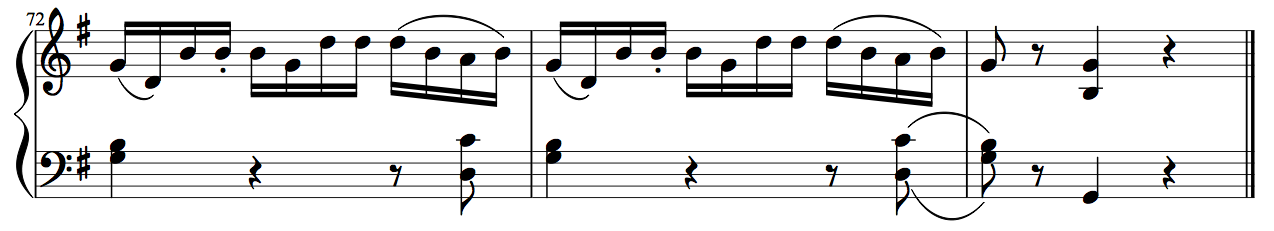

In [5]:
# Replace 'path_to_music_sheet.png' with the actual path to your music sheet image.
original = Image.open("C:/Users/kumra/OneDrive/Desktop/Git_Projects/CNN_Assignment1/kumar13-pkolimi-vborra-a1/part2/music1.png")
display(original)


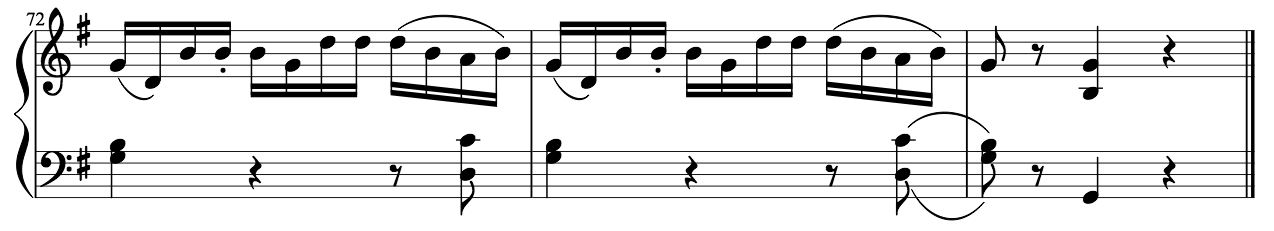

'Binary'

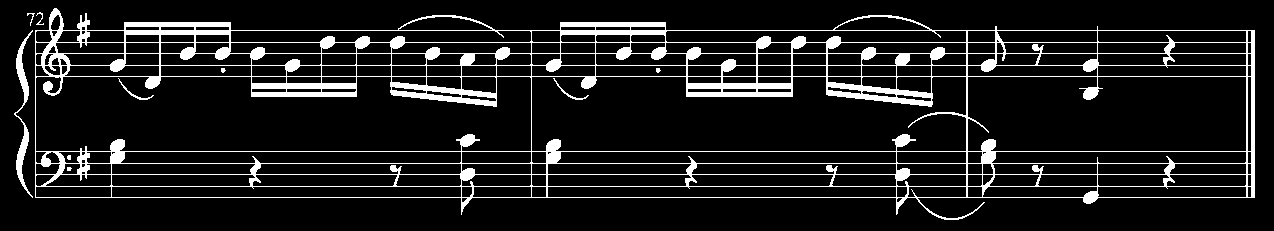

In [6]:
gray_img = original.convert('L')
display(gray_img)

# Create a binary image (thresholding at 128) for staff detection
gray_arr = np.array(gray_img, dtype=np.uint8)
bin_img = (gray_arr < 128).astype(np.uint8) * 255  # Multiply by 255 for visualization
bin_img_pil = Image.fromarray(bin_img.astype(np.uint8))
display('Binary',bin_img_pil)


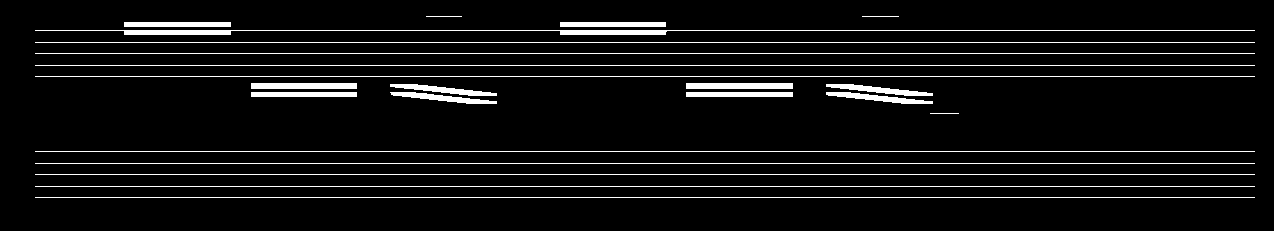

In [7]:

struct = np.ones((1, 25), dtype=np.uint8)
closed_img = morph_closing((gray_arr < 128).astype(np.uint8), struct)
closed_img_pil = Image.fromarray((closed_img*255).astype(np.uint8))
display(closed_img_pil)


Detected staff lines at rows: [30, 42, 53, 65, 76, 151, 163, 174, 186, 197]


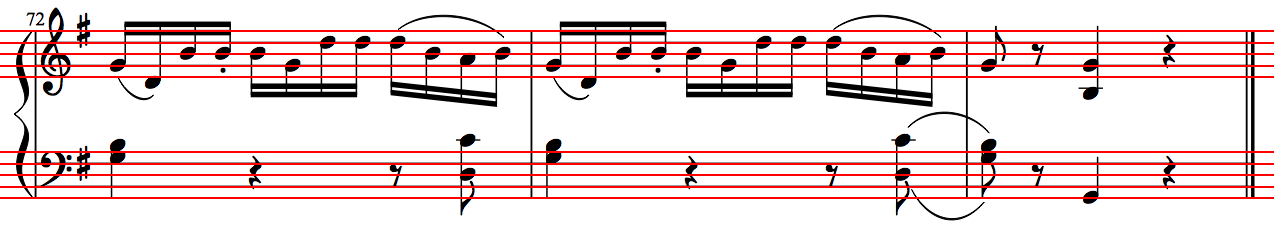

In [8]:
lines_found = staffl_detection(gray_arr, close_len=25, gap_thresh=8)
print("Detected staff lines at rows:", lines_found)


annotated_staff = original.copy() # Draw detected staff lines on a copy of the original image.
draw = ImageDraw.Draw(annotated_staff)
for y in lines_found:
    draw.line([(0, y), (annotated_staff.width, y)], fill="red", width=2)
display(annotated_staff)


In [9]:
treble_rows, bass_rows = treble_bass_grp(lines_found, big_jump=50)
spacing = lin_sp_estimation(lines_found)
print("Treble rows:", treble_rows)
print("Bass rows:", bass_rows)
print("Estimated staff spacing:", spacing)

Treble rows: [30, 42, 53, 65, 76]
Bass rows: [151, 163, 174, 186, 197]
Estimated staff spacing: 11


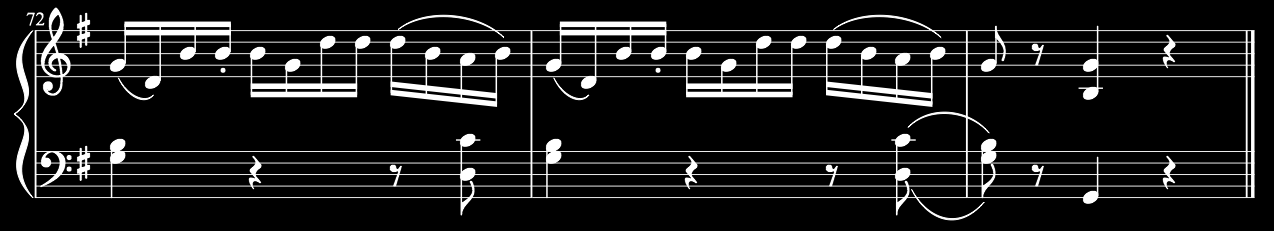

In [10]:
m_arr = inv_norm(original)
m_arr_disp = (m_arr * 255).astype(np.uint8)
m_arr_pil = Image.fromarray(m_arr_disp)
display(m_arr_pil)


Detected filled notes: 38


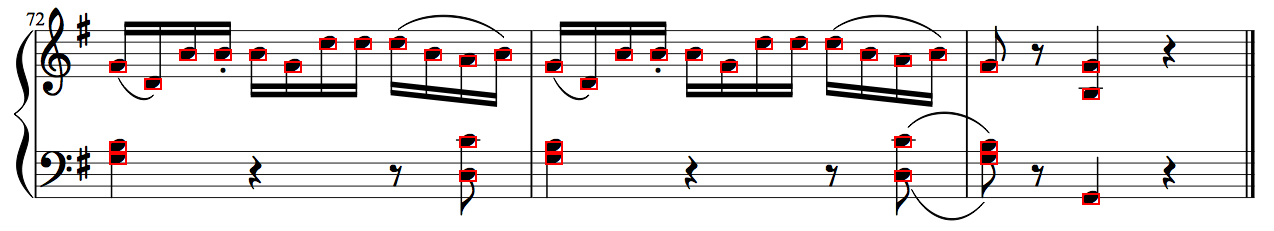

In [11]:
tmpl_fill = Image.open(filled)
fill_arr = inv_norm(tmpl_fill)
syms_f = dtct_symbols(m_arr, fill_arr, label='filled_note', conf_thresh=0.90)
syms_f = non_max_suppression(syms_f)
print("Detected filled notes:", len(syms_f))


annotated_notes = original.copy() # Drawing detected filled note bounding boxes on a copy of the original image.
draw_notes = ImageDraw.Draw(annotated_notes)
for sym in syms_f:
    draw_notes.rectangle([sym.x, sym.y, sym.x+sym.w, sym.y+sym.h], outline="red", width=2)
display(annotated_notes)


In [12]:

tmpl_quarter = Image.open(r_img) # Detect quarter rests
q_arr = inv_norm(tmpl_quarter)
syms_q = dtct_symbols(m_arr, q_arr, label='quarter_rest', conf_thresh=0.98)
syms_q = non_max_suppression(syms_q)
print("Detected quarter rests:", len(syms_q))


tmpl_eighth = Image.open(r_img2) # Detect eighth rests
e_arr = inv_norm(tmpl_eighth)
syms_e = dtct_symbols(m_arr, e_arr, label='eighth_rest', conf_thresh=0.89)
syms_e = non_max_suppression(syms_e)
print("Detected eighth rests:", len(syms_e))


Detected quarter rests: 7
Detected eighth rests: 7


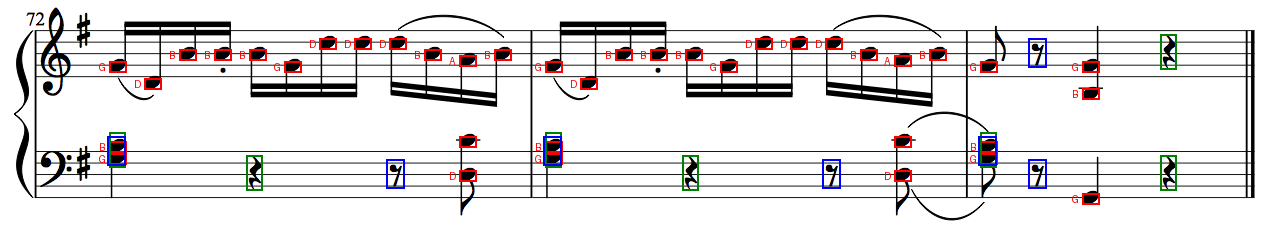

In [13]:
all_s_bols = []
all_s_bols.extend(syms_f)
all_s_bols.extend(syms_q)
all_s_bols.extend(syms_e)

final_syms = assign_pitch(all_s_bols, treble_rows, bass_rows, spacing)
final_annotated = annotate_s_bols(original.copy(), final_syms)
display(final_annotated)
